# Processed PPG: Theiler Window Sensitivity

Mục tiêu là chọn một Theiler window chung từ độ ổn định của đường dự báo và mức hỗ trợ dự báo. Việc chọn tham số không sử dụng mức phân tách Awake–Drowsy hoặc giá trị CC/NRMSE tốt nhất.

## Cell 1 — Configuration and data loading

In [1]:
from pathlib import Path
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from joblib import Parallel, delayed
from scipy.spatial import cKDTree


def find_project_root(start):
    """Find the repository directory from the current path."""
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
OUTPUT_DIR = (
    PROJECT_ROOT / "phase1" / "results" / "simplex_projection"
    / "processed"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from prediction.simplex_projection import (
    SimplexResult,
    prediction_metrics,
    simplex_projection,
)

M = 8
TAU_SECONDS = 0.16
HMAX_SECONDS = 4.0
WINDOW_SIZES = (60, 120, 180)
THEILER_SECONDS = np.array(
    [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
)
HORIZON_SECONDS = np.array(
    [
        0.04,
        0.08,
        0.12,
        0.16,
        0.20,
        0.28,
        0.40,
        0.60,
        0.80,
        1.00,
        1.20,
        1.60,
        2.00,
        2.40,
        2.80,
        3.20,
        3.60,
        4.00,
    ]
)
N_JOBS = min(6, os.cpu_count() or 1)
MIN_SUPPORT = 0.95
STABILITY_RATIO = 0.25


def session_number(path):
    """Return the numeric suffix of a session path."""
    return int(path.stem.rsplit("_", maxsplit=1)[-1])


session_paths = sorted(DATA_DIR.glob("sample_*.npz"), key=session_number)
sessions = [path.stem for path in session_paths]
tasks = []

for session in sessions:
    awake, drowsy = get_data(
        session,
        data_dir=DATA_DIR,
        window_sizes=WINDOW_SIZES,
        stationarity="processed",
    )
    for state, state_data in (("Awake", awake), ("Drowsy", drowsy)):
        for window_size in WINDOW_SIZES:
            batch = state_data[window_size]
            for index, signal in enumerate(batch["processed"]):
                tasks.append(
                    {
                        "session": session,
                        "state": state,
                        "window_size_s": window_size,
                        "window_id": int(batch["window_id"][index]),
                        "fs": float(batch["fs"]),
                        "signal": np.asarray(signal, dtype=float),
                    }
                )

coverage = (
    pd.DataFrame(tasks)
    .groupby(["window_size_s", "state"], observed=True)
    .size()
    .rename("n_windows")
    .reset_index()
)
conversion = pd.DataFrame(
    {
        "quantity": ["tau", *[f"W={value:g} s" for value in THEILER_SECONDS]],
        "seconds": [TAU_SECONDS, *THEILER_SECONDS],
    }
)
conversion["samples_25_hz"] = np.rint(conversion["seconds"] * 25).astype(int)
conversion["samples_50_hz"] = np.rint(conversion["seconds"] * 50).astype(int)

print(f"Sessions: {len(sessions)}")
print(f"Eligible Processed PPG windows: {len(tasks)}")
print(f"Parallel workers: {N_JOBS}")
display(coverage, conversion)

Sessions: 20
Eligible Processed PPG windows: 1544
Parallel workers: 6


,window_size_s,state,n_windows
0,60,Awake,596
1,60,Drowsy,305
2,120,Awake,269
3,120,Drowsy,136
4,180,Awake,161
5,180,Drowsy,77


,quantity,seconds,samples_25_hz,samples_50_hz
0,tau,0.16,4,8
1,W=0 s,0.00,0,0
2,W=0.2 s,0.20,5,10
3,W=0.4 s,0.40,10,20
4,W=0.6 s,0.60,15,30
5,W=0.8 s,0.80,20,40
6,W=1 s,1.00,25,50
7,W=1.5 s,1.50,38,75
8,W=2 s,2.00,50,100


## Cell 2 — Full Theiler sensitivity

In [2]:
def standardize_signal(signal):
    """Return a finite signal with zero mean and unit variance."""
    signal = np.asarray(signal, dtype=float)
    scale = np.std(signal)
    if signal.ndim != 1 or not np.all(np.isfinite(signal)):
        raise ValueError("Signal must be finite and one-dimensional.")
    if scale <= 0:
        raise ValueError("Signal must have non-zero variance.")
    return (signal - np.mean(signal)) / scale


def build_embedding(signal, tau, m, horizon):
    """Build delay states, future targets, and state times."""
    start = (m - 1) * tau
    times = np.arange(start, len(signal) - horizon)
    offsets = np.arange(m) * tau
    states = signal[times[:, None] - offsets[None, :]]
    targets = signal[times + horizon]
    return states, targets, times


def simplex_all_theiler(signal, tau, m, horizon, theiler_values):
    """Run exact simplex prediction for several Theiler windows."""
    states, targets, times = build_embedding(signal, tau, m, horizon)
    n_neighbors = m + 1
    max_theiler = int(np.max(theiler_values))
    query_k = min(len(times), 2 * max_theiler + n_neighbors + 1)

    if query_k < n_neighbors + 1:
        raise ValueError("Not enough embedded states for prediction.")

    distances, indices = cKDTree(states).query(
        states,
        k=query_k,
        workers=1,
    )
    time_distance = np.abs(times[indices] - times[:, None])
    results = {}

    for theiler in theiler_values:
        admissible = time_distance > int(theiler)
        rank = np.cumsum(admissible, axis=1)
        selected = admissible & (rank <= n_neighbors)
        counts = np.sum(selected, axis=1)
        valid = counts == n_neighbors
        predictions = np.full(len(states), np.nan)

        if np.any(valid):
            selected_valid = selected[valid]
            valid_distances = distances[valid][selected_valid]
            valid_indices = indices[valid][selected_valid]
            valid_distances = valid_distances.reshape(-1, n_neighbors)
            valid_indices = valid_indices.reshape(-1, n_neighbors)

            zero_mask = np.isclose(
                valid_distances,
                0.0,
                rtol=0.0,
                atol=np.finfo(float).eps,
            )
            has_zero = np.any(zero_mask, axis=1)
            weights = np.zeros_like(valid_distances)

            if np.any(has_zero):
                weights[has_zero] = (
                    zero_mask[has_zero]
                    / np.sum(zero_mask[has_zero], axis=1, keepdims=True)
                )

            nonzero = ~has_zero
            if np.any(nonzero):
                reference = valid_distances[nonzero, :1]
                raw_weights = np.exp(-valid_distances[nonzero] / reference)
                weights[nonzero] = (
                    raw_weights
                    / np.sum(raw_weights, axis=1, keepdims=True)
                )

            neighbor_targets = targets[valid_indices]
            predictions[valid] = np.sum(weights * neighbor_targets, axis=1)

        results[int(theiler)] = SimplexResult(
            horizon=horizon,
            times=times,
            y_true=targets,
            y_pred=predictions,
            valid=np.isfinite(predictions),
        )

    return results


def evaluate_window(task):
    """Evaluate every horizon and Theiler value for one window."""
    signal = standardize_signal(task["signal"])
    fs = task["fs"]
    tau = int(round(TAU_SECONDS * fs))
    theiler_samples = np.rint(THEILER_SECONDS * fs).astype(int)
    horizon_samples = np.rint(HORIZON_SECONDS * fs).astype(int)
    rows = []

    for horizon_s, horizon in zip(HORIZON_SECONDS, horizon_samples):
        predictions = simplex_all_theiler(
            signal=signal,
            tau=tau,
            m=M,
            horizon=int(horizon),
            theiler_values=theiler_samples,
        )
        for theiler_s, theiler in zip(THEILER_SECONDS, theiler_samples):
            result = predictions[int(theiler)]
            metrics = prediction_metrics(result, nrmse_scale=1.0)
            rows.append(
                {
                    "session": task["session"],
                    "state": task["state"],
                    "window_size_s": task["window_size_s"],
                    "window_id": task["window_id"],
                    "fs": fs,
                    "tau_samples": tau,
                    "theiler_seconds": float(theiler_s),
                    "theiler_samples": int(theiler),
                    "horizon_seconds": float(horizon_s),
                    "horizon_samples": int(horizon),
                    "cc": metrics.cc,
                    "nrmse": metrics.nrmse,
                    "valid_fraction": metrics.n_valid / len(result.y_true),
                }
            )
    return rows


# Verify the batched implementation against the public core.
smoke_task = tasks[0]
smoke_signal = standardize_signal(smoke_task["signal"])
smoke_fs = smoke_task["fs"]
smoke_tau = int(round(TAU_SECONDS * smoke_fs))
smoke_horizon = int(round(0.40 * smoke_fs))
smoke_theiler = np.rint(THEILER_SECONDS * smoke_fs).astype(int)
batched = simplex_all_theiler(
    smoke_signal,
    smoke_tau,
    M,
    smoke_horizon,
    smoke_theiler,
)
max_difference = 0.0

for theiler in smoke_theiler:
    reference = simplex_projection(
        smoke_signal,
        smoke_tau,
        M,
        smoke_horizon,
        int(theiler),
    )
    difference = np.nanmax(
        np.abs(reference.y_pred - batched[int(theiler)].y_pred)
    )
    max_difference = max(max_difference, float(difference))

assert max_difference <= 1e-12
print(f"Core equivalence max absolute difference: {max_difference:.3e}")

start_time = time.perf_counter()
window_rows = Parallel(n_jobs=N_JOBS, batch_size=1, verbose=5)(
    delayed(evaluate_window)(task) for task in tasks
)
sensitivity_window = pd.DataFrame(
    [row for task_rows in window_rows for row in task_rows]
)
runtime_minutes = (time.perf_counter() - start_time) / 60

session_keys = [
    "session",
    "state",
    "window_size_s",
    "theiler_seconds",
    "horizon_seconds",
]
sensitivity_session = (
    sensitivity_window
    .groupby(session_keys, observed=True)
    .agg(
        cc=("cc", "mean"),
        nrmse=("nrmse", "mean"),
        valid_fraction=("valid_fraction", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .reset_index()
)

expected_rows = len(tasks) * len(THEILER_SECONDS) * len(HORIZON_SECONDS)
assert len(sensitivity_window) == expected_rows
assert sensitivity_window[["cc", "nrmse"]].notna().all().all()

print(f"Window-level rows held in memory: {len(sensitivity_window):,}")
print(f"Session-level rows: {len(sensitivity_session):,}")
print(f"Runtime: {runtime_minutes:.2f} minutes")
print(
    "Minimum prediction support: "
    f"{sensitivity_window['valid_fraction'].min():.4f}"
)

Core equivalence max absolute difference: 4.441e-16


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    3.5s


[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:   39.2s


[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:  1.0min


...

[Parallel(n_jobs=6)]: Done 870 tasks      | elapsed:  3.8min


[Parallel(n_jobs=6)]: Done 1140 tasks      | elapsed:  4.9min


[Parallel(n_jobs=6)]: Done 1446 tasks      | elapsed:  6.2min


[Parallel(n_jobs=6)]: Done 1544 out of 1544 | elapsed:  6.6min finished


Window-level rows held in memory: 222,336
Session-level rows: 17,280
Runtime: 6.64 minutes
Minimum prediction support: 1.0000


## Cell 3 — Adjacent-curve stability

In [3]:
def percentile_25(values):
    """Return the 25th percentile."""
    return values.quantile(0.25)


def percentile_75(values):
    """Return the 75th percentile."""
    return values.quantile(0.75)


pair_keys = ["session", "state", "window_size_s", "horizon_seconds"]
adjacent_parts = []

for lower_w, upper_w in zip(THEILER_SECONDS[:-1], THEILER_SECONDS[1:]):
    lower = sensitivity_session.loc[
        sensitivity_session["theiler_seconds"].eq(lower_w),
        pair_keys + ["cc", "nrmse"],
    ]
    upper = sensitivity_session.loc[
        sensitivity_session["theiler_seconds"].eq(upper_w),
        pair_keys + ["cc", "nrmse", "valid_fraction"],
    ]
    paired = lower.merge(
        upper,
        on=pair_keys,
        suffixes=("_lower", "_upper"),
        validate="one_to_one",
    )
    paired["d_cc"] = np.abs(paired["cc_upper"] - paired["cc_lower"])
    paired["d_nrmse"] = np.abs(
        paired["nrmse_upper"] - paired["nrmse_lower"]
    )
    combination = (
        paired
        .groupby(["session", "state", "window_size_s"], observed=True)
        .agg(
            d_cc=("d_cc", "mean"),
            d_nrmse=("d_nrmse", "mean"),
            valid_fraction=("valid_fraction", "mean"),
        )
        .reset_index()
    )
    combination["lower_w_seconds"] = float(lower_w)
    combination["upper_w_seconds"] = float(upper_w)
    adjacent_parts.append(combination)

adjacent_combinations = pd.concat(adjacent_parts, ignore_index=True)
stability_summary = (
    adjacent_combinations
    .groupby(["lower_w_seconds", "upper_w_seconds"], observed=True)
    .agg(
        n_combinations=("d_cc", "size"),
        median_d_cc=("d_cc", "median"),
        q25_d_cc=("d_cc", percentile_25),
        q75_d_cc=("d_cc", percentile_75),
        median_d_nrmse=("d_nrmse", "median"),
        q25_d_nrmse=("d_nrmse", percentile_25),
        q75_d_nrmse=("d_nrmse", percentile_75),
        median_support=("valid_fraction", "median"),
        minimum_support=("valid_fraction", "min"),
    )
    .reset_index()
)

support_combinations = (
    sensitivity_session
    .groupby(
        ["session", "state", "window_size_s", "theiler_seconds"],
        observed=True,
    )
    ["valid_fraction"]
    .mean()
    .reset_index()
)
support_summary = (
    support_combinations
    .groupby("theiler_seconds", observed=True)
    .agg(
        median_support=("valid_fraction", "median"),
        q25_support=("valid_fraction", percentile_25),
        q75_support=("valid_fraction", percentile_75),
        minimum_support=("valid_fraction", "min"),
    )
    .reset_index()
)

# Normalize by step width because the W grid is not uniformly spaced.
step_width = (
    stability_summary["upper_w_seconds"]
    - stability_summary["lower_w_seconds"]
)
stability_summary["rate_cc"] = stability_summary["median_d_cc"] / step_width
stability_summary["rate_nrmse"] = (
    stability_summary["median_d_nrmse"] / step_width
)
stability_summary["relative_rate_cc"] = (
    stability_summary["rate_cc"] / stability_summary["rate_cc"].max()
)
stability_summary["relative_rate_nrmse"] = (
    stability_summary["rate_nrmse"]
    / stability_summary["rate_nrmse"].max()
)
stability_summary["stable_pair"] = (
    stability_summary["relative_rate_cc"].le(STABILITY_RATIO)
    & stability_summary["relative_rate_nrmse"].le(STABILITY_RATIO)
    & stability_summary["minimum_support"].ge(MIN_SUPPORT)
)
peak_position = max(
    int(stability_summary["rate_cc"].to_numpy().argmax()),
    int(stability_summary["rate_nrmse"].to_numpy().argmax()),
)
stability_summary["after_dominant_transition"] = (
    np.arange(len(stability_summary)) > peak_position
)
stability_summary["sustained_stability"] = [
    bool(stability_summary["stable_pair"].iloc[index:].all())
    for index in range(len(stability_summary))
]

eligible = stability_summary.loc[
    stability_summary["after_dominant_transition"]
    & stability_summary["sustained_stability"]
]
if not eligible.empty:
    selected_w = float(eligible.iloc[0]["upper_w_seconds"])
    selection_rule = (
        "earliest sustained stable transition after the dominant change"
    )
else:
    eligible = stability_summary.loc[
        stability_summary["after_dominant_transition"]
        & stability_summary["stable_pair"]
    ]
    if not eligible.empty:
        selected_w = float(eligible.iloc[0]["upper_w_seconds"])
        selection_rule = "first stable transition after the dominant change"
    else:
        selected_w = float(THEILER_SECONDS[-1])
        selection_rule = "largest candidate; stability criterion not reached"

stability_summary["selected"] = stability_summary["upper_w_seconds"].eq(
    selected_w
)
summary_path = OUTPUT_DIR / "processed_theiler_sensitivity_summary.csv"
stability_summary.to_csv(summary_path, index=False)

stratified_stability = (
    adjacent_combinations
    .groupby(
        ["state", "window_size_s", "lower_w_seconds", "upper_w_seconds"],
        observed=True,
    )
    .agg(
        n_sessions=("session", "nunique"),
        median_d_cc=("d_cc", "median"),
        median_d_nrmse=("d_nrmse", "median"),
        minimum_support=("valid_fraction", "min"),
    )
    .reset_index()
)

print(f"Selected W: {selected_w:.2f} s ({selection_rule})")
display(stability_summary.round(5))
display(
    stratified_stability
    .groupby(["state", "window_size_s"], observed=True)
    .agg(
        n_sessions=("n_sessions", "max"),
        median_d_cc=("median_d_cc", "median"),
        median_d_nrmse=("median_d_nrmse", "median"),
        minimum_support=("minimum_support", "min"),
    )
    .reset_index()
    .round(5)
)

Selected W: 1.00 s (earliest sustained stable transition after the dominant change)


,lower_w_seconds,upper_w_seconds,n_combinations,median_d_cc,q25_d_cc,q75_d_cc,median_d_nrmse,q25_d_nrmse,q75_d_nrmse,median_support,minimum_support,rate_cc,rate_nrmse,relative_rate_cc,relative_rate_nrmse,stable_pair,after_dominant_transition,sustained_stability,selected
0,0.0,0.2,120,0.00355,0.00144,0.00779,0.00337,0.00138,0.00716,1.0,1.0,0.01775,0.01685,0.17529,0.21584,True,False,False,False
1,0.2,0.4,120,0.00000,0.00000,0.00003,0.00000,0.00000,0.00005,1.0,1.0,0.00001,0.00001,0.00011,0.00014,True,False,False,False
2,0.4,0.6,120,0.00214,0.00021,0.00922,0.00206,0.00024,0.00741,1.0,1.0,0.01069,0.01030,0.10552,0.13189,True,False,False,False
3,0.6,0.8,120,0.02025,0.01556,0.02760,0.01561,0.01216,0.02102,1.0,1.0,0.10127,0.07807,1.00000,1.00000,False,False,False,False
4,0.8,1.0,120,0.00361,0.00046,0.00914,0.00326,0.00049,0.00752,1.0,1.0,0.01803,0.01630,0.17800,0.20877,True,True,True,True
5,1.0,1.5,120,0.00889,0.00478,0.01323,0.00794,0.00490,0.01109,1.0,1.0,0.01779,0.01587,0.17565,0.20334,True,True,True,False
6,1.5,2.0,120,0.00703,0.00495,0.00934,0.00644,0.00455,0.00852,1.0,1.0,0.01407,0.01288,0.13891,0.16503,True,True,True,False


,state,window_size_s,n_sessions,median_d_cc,median_d_nrmse,minimum_support
0,Awake,60,20,0.00591,0.00533,1.0
1,Awake,120,20,0.00374,0.00359,1.0
2,Awake,180,20,0.00313,0.00337,1.0
3,Drowsy,60,20,0.00551,0.00503,1.0
4,Drowsy,120,20,0.00301,0.00314,1.0
5,Drowsy,180,20,0.00248,0.00229,1.0


## Cell 4 — Publication-ready evidence figure

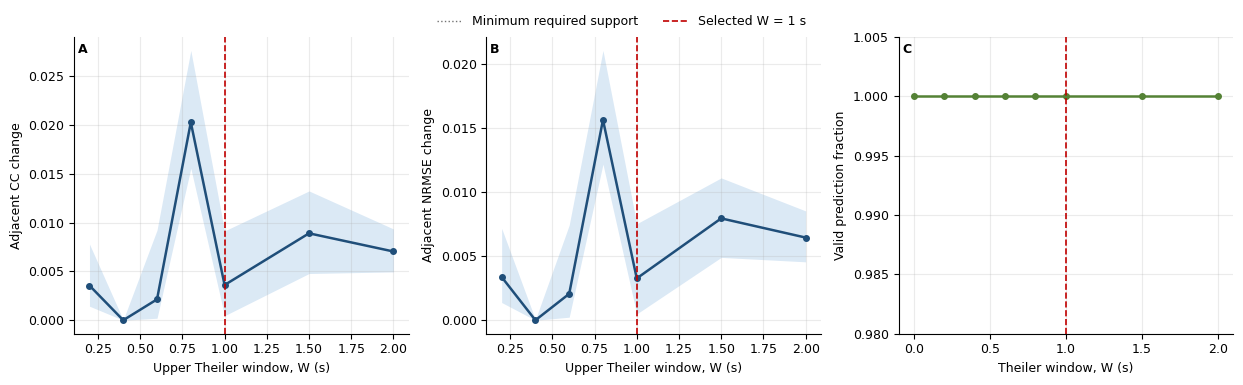

Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\simplex_projection\processed\processed_theiler_sensitivity.png


In [4]:
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

figure, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
stability_x = stability_summary["upper_w_seconds"].to_numpy()
support_x = support_summary["theiler_seconds"].to_numpy()

panels = (
    ("median_d_cc", "q25_d_cc", "q75_d_cc", "Adjacent CC change"),
    (
        "median_d_nrmse",
        "q25_d_nrmse",
        "q75_d_nrmse",
        "Adjacent NRMSE change",
    ),
)

for axis, (median, lower, upper, label) in zip(axes[:2], panels):
    axis.plot(
        stability_x,
        stability_summary[median],
        color="#1f4e79",
        marker="o",
        linewidth=1.8,
        markersize=4,
    )
    axis.fill_between(
        stability_x,
        stability_summary[lower],
        stability_summary[upper],
        color="#5b9bd5",
        alpha=0.22,
        linewidth=0,
    )
    axis.set_xlabel("Upper Theiler window, W (s)")
    axis.set_ylabel(label)

axes[2].plot(
    support_x,
    support_summary["median_support"],
    color="#548235",
    marker="o",
    linewidth=1.8,
    markersize=4,
)
axes[2].fill_between(
    support_x,
    support_summary["q25_support"],
    support_summary["q75_support"],
    color="#70ad47",
    alpha=0.22,
    linewidth=0,
)
axes[2].axhline(
    MIN_SUPPORT,
    color="0.45",
    linestyle=":",
    linewidth=1.0,
    label="Minimum required support",
)
axes[2].set_xlabel("Theiler window, W (s)")
axes[2].set_ylabel("Valid prediction fraction")
axes[2].set_ylim(
    max(0.0, support_summary["minimum_support"].min() - 0.02),
    1.005,
)

for label, axis in zip(("A", "B", "C"), axes):
    axis.axvline(
        selected_w,
        color="#c00000",
        linestyle="--",
        linewidth=1.2,
        label=f"Selected W = {selected_w:g} s",
    )
    axis.text(
        0.01,
        0.98,
        label,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
    )

handles, labels = axes[2].get_legend_handles_labels()
unique = dict(zip(labels, handles))
figure.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
)
figure.tight_layout()

figure_path = OUTPUT_DIR / "processed_theiler_sensitivity.png"
figure.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {figure_path}")

## Cell 5 — Freeze the Theiler window

In [5]:
selected_row = stability_summary.loc[
    stability_summary["upper_w_seconds"].eq(selected_w)
].iloc[0]
selected_samples_25 = int(round(selected_w * 25))
selected_samples_50 = int(round(selected_w * 50))

freeze_table = pd.DataFrame(
    {
        "Parameter": [
            "Selected W (s)",
            "W at 25 Hz (samples)",
            "W at 50 Hz (samples)",
            "Median adjacent CC change",
            "Median adjacent NRMSE change",
            "Minimum valid prediction fraction",
        ],
        "Value": [
            selected_w,
            selected_samples_25,
            selected_samples_50,
            selected_row["median_d_cc"],
            selected_row["median_d_nrmse"],
            selected_row["minimum_support"],
        ],
    }
)

freeze_note = (
    "### Frozen Theiler window\n\n"
    f"Theiler window được cố định ở **W = {selected_w:.2f} s**, "
    f"tương ứng **{selected_samples_25} samples tại 25 Hz** và "
    f"**{selected_samples_50} samples tại 50 Hz**.\n\n"
    f"Đây là {selection_rule} theo tiêu chí: sau chuyển tiếp chi phối, "
    "tốc độ thay đổi trung vị của cả đường CC và NRMSE không vượt quá "
    f"{STABILITY_RATIO:.0%} tốc độ thay đổi lớn nhất và duy trì đến hết "
    "grid, đồng thời valid prediction fraction không thấp hơn "
    f"{MIN_SUPPORT:.0%}. Tiêu chí được tính sau khi gộp window trong từng "
    "session–state–window size và không sử dụng độ phân tách Awake–Drowsy "
    "hay cực trị của prediction skill.\n\n"
    f"Các tham số cố định còn lại: Processed PPG, m = {M}, "
    f"tau = {TAU_SECONDS:.2f} s, k = m + 1, Euclidean distance, "
    "exponential weighting, leave-one-out prediction và "
    f"Hmax = {HMAX_SECONDS:.1f} s."
)

display(freeze_table)
display(Markdown(freeze_note))

saved_outputs = sorted(
    path.name
    for path in OUTPUT_DIR.glob("processed_theiler_sensitivity*")
)
print("Sensitivity outputs:")
for name in saved_outputs:
    print(f"- {name}")

,Parameter,Value
0,Selected W (s),1.000000
1,W at 25 Hz (samples),25.000000
2,W at 50 Hz (samples),50.000000
3,Median adjacent CC change,0.003605
4,Median adjacent NRMSE change,0.003260
5,Minimum valid prediction fraction,1.000000


### Frozen Theiler window

Theiler window được cố định ở **W = 1.00 s**, tương ứng **25 samples tại 25 Hz** và **50 samples tại 50 Hz**.

Đây là `earliest sustained stable transition after the dominant change` theo tiêu chí: sau chuyển tiếp chi phối, tốc độ thay đổi trung vị của cả đường CC và NRMSE không vượt quá 25% tốc độ thay đổi lớn nhất và duy trì đến hết grid, đồng thời valid prediction fraction không thấp hơn 95%. Tiêu chí được tính sau khi gộp window trong từng session–state–window size và không sử dụng độ phân tách Awake–Drowsy hay cực trị của prediction skill.

Các tham số cố định còn lại: Processed PPG, `m = 8`, `tau = 0.16 s`, `k = m + 1`, Euclidean distance, exponential weighting, leave-one-out prediction và `Hmax = 4.0 s`.

Sensitivity outputs:
- processed_theiler_sensitivity.png
- processed_theiler_sensitivity_summary.csv


# RQ2 — Final Simplex Prediction Experiment

Phân tích toàn bộ dataset với protocol đã đóng băng. Statistical hierarchy được giữ ở tầng `Window → Session × State × Window size → Across-session`; không tuning thêm tham số và không pool window giữa các session.

## Part A — Processed PPG

### Cell 1 — Load and coverage

In [6]:
from dataloader.loader import load_segmented_session

SUMMARY_DIR = (
    PROJECT_ROOT / "phase1" / "results" / "simplex_projection" / "summary"
)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_M = 8
PROCESSED_TAU_SECONDS = 0.16
RAW_TAU_SECONDS = 0.20
FROZEN_THEILER_SECONDS = 1.0
LOW_WINDOW_THRESHOLD = 5
STATE_ORDER = ("Awake", "Drowsy")
STATE_CODES = {"Awake": 0, "Drowsy": 1}
STATE_COLORS = {"Awake": "#1f77b4", "Drowsy": "#d62728"}
SIZE_COLORS = {60: "#4472c4", 120: "#70ad47", 180: "#ed7d31"}
REPRESENTATION_COLORS = {"Processed": "#4472c4", "Raw": "#ed7d31"}

assert PREDICTION_M == M
assert np.isclose(PROCESSED_TAU_SECONDS, TAU_SECONDS)
assert np.isclose(FROZEN_THEILER_SECONDS, selected_w)
assert np.isclose(HORIZON_SECONDS.max(), HMAX_SECONDS)


def load_processed_prediction_tasks():
    """Load all Processed PPG windows eligible for final prediction."""
    prediction_tasks = []
    for session in sessions:
        awake, drowsy = get_data(
            session,
            data_dir=DATA_DIR,
            window_sizes=WINDOW_SIZES,
            stationarity="processed",
        )
        for state, state_data in zip(STATE_ORDER, (awake, drowsy)):
            for window_size in WINDOW_SIZES:
                batch = state_data[window_size]
                for index, signal in enumerate(batch["processed"]):
                    prediction_tasks.append(
                        {
                            "session": session,
                            "state": state,
                            "window_size_s": window_size,
                            "window_id": int(batch["window_id"][index]),
                            "fs": float(batch["fs"]),
                            "signal": np.asarray(signal, dtype=float),
                        }
                    )
    return prediction_tasks


def summarize_task_coverage(prediction_tasks):
    """Summarize window coverage for each analysis combination."""
    task_frame = pd.DataFrame(
        [
            {
                key: task[key]
                for key in ("session", "state", "window_size_s", "window_id")
            }
            for task in prediction_tasks
        ]
    )
    coverage = (
        task_frame
        .groupby(["session", "state", "window_size_s"], observed=True)
        .agg(n_windows=("window_id", "nunique"))
        .reset_index()
    )
    complete_index = pd.MultiIndex.from_product(
        [sessions, STATE_ORDER, WINDOW_SIZES],
        names=["session", "state", "window_size_s"],
    )
    audit = (
        coverage
        .set_index(["session", "state", "window_size_s"])
        .reindex(complete_index, fill_value=0)
        .reset_index()
    )
    audit["coverage_status"] = np.select(
        [
            audit["n_windows"].eq(0),
            audit["n_windows"].lt(LOW_WINDOW_THRESHOLD),
        ],
        ["missing", "low_support"],
        default="adequate",
    )
    return coverage, audit


processed_tasks = load_processed_prediction_tasks()
processed_coverage, processed_coverage_audit = summarize_task_coverage(
    processed_tasks
)

print(f"Processed eligible windows: {len(processed_tasks):,}")
display(
    processed_coverage
    .groupby(["state", "window_size_s"], observed=True)
    .agg(
        n_sessions=("session", "nunique"),
        n_windows=("n_windows", "sum"),
        minimum_per_session=("n_windows", "min"),
    )
    .reset_index()
)
display(
    processed_coverage_audit
    .groupby("coverage_status", observed=True)
    .size()
    .rename("n_combinations")
    .reset_index()
)

Processed eligible windows: 1,544


,state,window_size_s,n_sessions,n_windows,minimum_per_session
0,Awake,60,20,596,19
1,Awake,120,20,269,8
2,Awake,180,20,161,5
3,Drowsy,60,20,305,6
4,Drowsy,120,20,136,1
5,Drowsy,180,20,77,1


,coverage_status,n_combinations
0,adequate,102
1,low_support,18


### Cell 2 — Frozen prediction

In [7]:
def evaluate_frozen_task(task, tau_seconds, representation):
    """Run the frozen prediction protocol for one signal window."""
    signal = standardize_signal(task["signal"])
    fs = task["fs"]
    tau = int(round(tau_seconds * fs))
    theiler = int(round(FROZEN_THEILER_SECONDS * fs))
    horizon_samples = np.rint(HORIZON_SECONDS * fs).astype(int)
    rows = []

    for horizon_s, horizon in zip(HORIZON_SECONDS, horizon_samples):
        try:
            result = simplex_all_theiler(
                signal=signal,
                tau=tau,
                m=PREDICTION_M,
                horizon=int(horizon),
                theiler_values=np.array([theiler]),
            )[theiler]
            metrics = prediction_metrics(result, nrmse_scale=1.0)
            status = "ok"
            error = ""
        except (ValueError, FloatingPointError, RuntimeError) as exc:
            metrics = None
            result = None
            status = "failed"
            error = str(exc)

        rows.append(
            {
                "session": task["session"],
                "state": task["state"],
                "representation": representation,
                "window_size_s": task["window_size_s"],
                "window_id": task["window_id"],
                "fs": fs,
                "tau_seconds": tau_seconds,
                "tau_samples": tau,
                "theiler_seconds": FROZEN_THEILER_SECONDS,
                "theiler_samples": theiler,
                "horizon_seconds": float(horizon_s),
                "horizon_samples": int(horizon),
                "cc": np.nan if metrics is None else metrics.cc,
                "nrmse": np.nan if metrics is None else metrics.nrmse,
                "valid_fraction": (
                    0.0
                    if metrics is None
                    else metrics.n_valid / len(result.y_true)
                ),
                "status": status,
                "error": error,
            }
        )
    return rows


# Reuse the exact W = 1 s slice computed in the sensitivity experiment.
processed_window_results = sensitivity_window.loc[
    sensitivity_window["theiler_seconds"].eq(FROZEN_THEILER_SECONDS)
].copy()
processed_window_results["representation"] = "Processed"
processed_window_results["tau_seconds"] = PROCESSED_TAU_SECONDS
processed_window_results["status"] = "ok"
processed_window_results["error"] = ""

expected_processed_rows = len(processed_tasks) * len(HORIZON_SECONDS)
assert len(processed_window_results) == expected_processed_rows
assert processed_window_results[["cc", "nrmse"]].notna().all().all()

processed_qc = pd.DataFrame(
    {
        "n_rows": [len(processed_window_results)],
        "failed_rows": [processed_window_results["status"].ne("ok").sum()],
        "undefined_cc": [processed_window_results["cc"].isna().sum()],
        "undefined_nrmse": [processed_window_results["nrmse"].isna().sum()],
        "minimum_valid_fraction": [
            processed_window_results["valid_fraction"].min()
        ],
    }
)
display(processed_qc)

,n_rows,failed_rows,undefined_cc,undefined_nrmse,minimum_valid_fraction
0,27792,0,0,0,1.0


### Cell 3 — Session-level aggregation

In [8]:
def interquartile_range(values):
    """Return the interquartile range of numeric values."""
    return values.quantile(0.75) - values.quantile(0.25)


def aggregate_session_results(window_results):
    """Aggregate valid window metrics within each session hierarchy."""
    valid = window_results.loc[
        window_results["status"].eq("ok")
        & window_results["cc"].notna()
        & window_results["nrmse"].notna()
    ]
    group_keys = [
        "session",
        "state",
        "representation",
        "window_size_s",
        "horizon_seconds",
    ]
    return (
        valid
        .groupby(group_keys, observed=True)
        .agg(
            central_cc=("cc", "mean"),
            variability_cc=("cc", "std"),
            median_cc=("cc", "median"),
            iqr_cc=("cc", interquartile_range),
            central_nrmse=("nrmse", "mean"),
            variability_nrmse=("nrmse", "std"),
            median_nrmse=("nrmse", "median"),
            iqr_nrmse=("nrmse", interquartile_range),
            mean_valid_fraction=("valid_fraction", "mean"),
            minimum_valid_fraction=("valid_fraction", "min"),
            n_windows=("window_id", "nunique"),
        )
        .reset_index()
    )


def calculate_state_differences(session_summary):
    """Calculate paired Drowsy-minus-Awake session curves."""
    keys = [
        "session",
        "representation",
        "window_size_s",
        "horizon_seconds",
    ]
    columns = keys + ["central_cc", "central_nrmse", "n_windows"]
    awake = session_summary.loc[
        session_summary["state"].eq("Awake"), columns
    ]
    drowsy = session_summary.loc[
        session_summary["state"].eq("Drowsy"), columns
    ]
    paired = awake.merge(
        drowsy,
        on=keys,
        suffixes=("_awake", "_drowsy"),
        validate="one_to_one",
    )
    paired["delta_cc"] = (
        paired["central_cc_drowsy"] - paired["central_cc_awake"]
    )
    paired["delta_nrmse"] = (
        paired["central_nrmse_drowsy"]
        - paired["central_nrmse_awake"]
    )
    return paired


processed_session_summary = aggregate_session_results(
    processed_window_results
)
processed_state_differences = calculate_state_differences(
    processed_session_summary
)

processed_pair_coverage = (
    processed_state_differences
    .groupby("window_size_s", observed=True)
    .agg(
        n_paired_sessions=("session", "nunique"),
        n_horizons=("horizon_seconds", "nunique"),
    )
    .reset_index()
)

print(f"Processed session-level rows: {len(processed_session_summary):,}")
display(processed_pair_coverage)
display(processed_session_summary.head())

Processed session-level rows: 2,160


,window_size_s,n_paired_sessions,n_horizons
0,60,20,18
1,120,20,18
2,180,20,18


,session,state,representation,window_size_s,horizon_seconds,central_cc,variability_cc,median_cc,iqr_cc,central_nrmse,variability_nrmse,median_nrmse,iqr_nrmse,mean_valid_fraction,minimum_valid_fraction,n_windows
0,sample_1,Awake,Processed,60,0.04,0.981720,0.007203,0.983120,0.006491,0.187632,0.032872,0.182970,0.034422,1.0,1.0,24
1,sample_1,Awake,Processed,60,0.08,0.960574,0.014541,0.964608,0.014045,0.274264,0.045659,0.264263,0.050210,1.0,1.0,24
2,sample_1,Awake,Processed,60,0.12,0.961188,0.013342,0.965813,0.016844,0.272627,0.043113,0.260745,0.059884,1.0,1.0,24
3,sample_1,Awake,Processed,60,0.16,0.959902,0.012974,0.963838,0.012730,0.277479,0.040696,0.267393,0.044052,1.0,1.0,24
4,sample_1,Awake,Processed,60,0.20,0.956067,0.015480,0.958421,0.012880,0.289654,0.044917,0.284852,0.042628,1.0,1.0,24


### Cell 4 — Processed final outputs

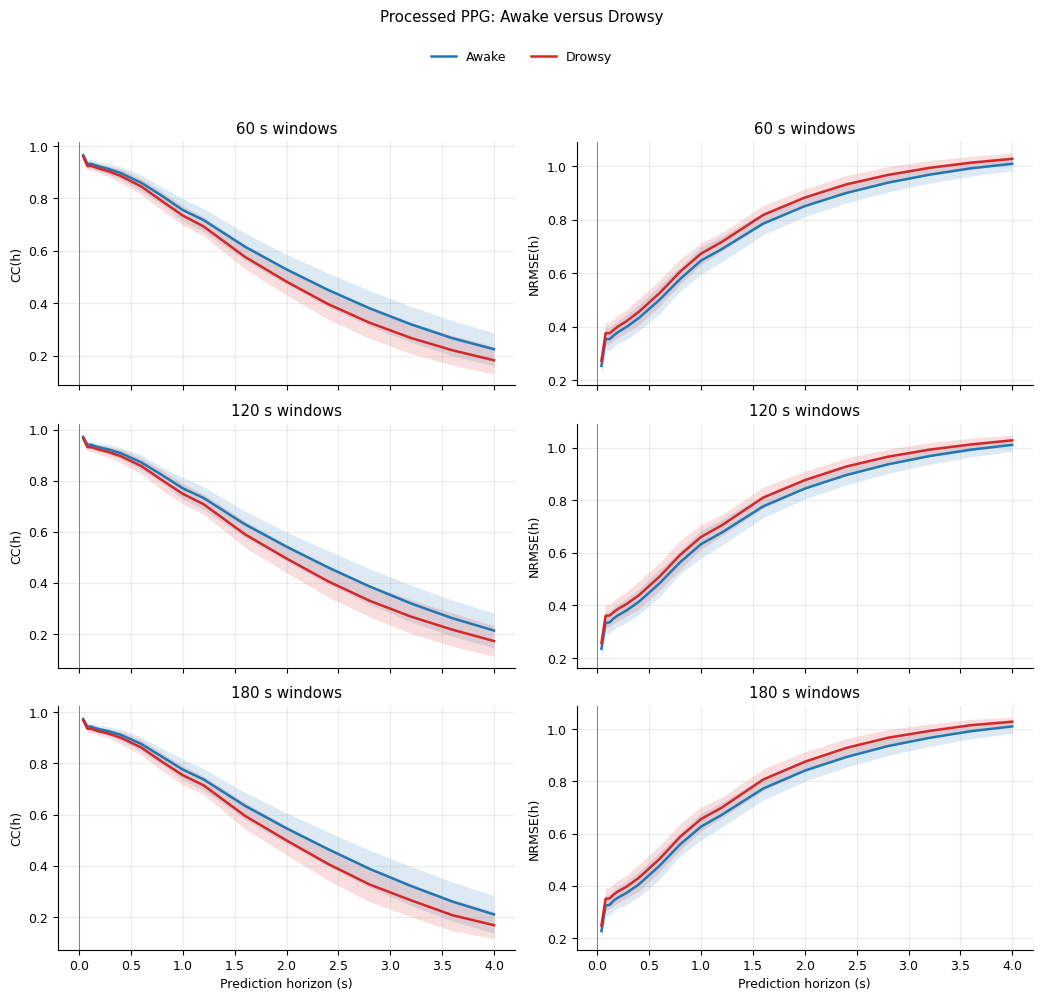

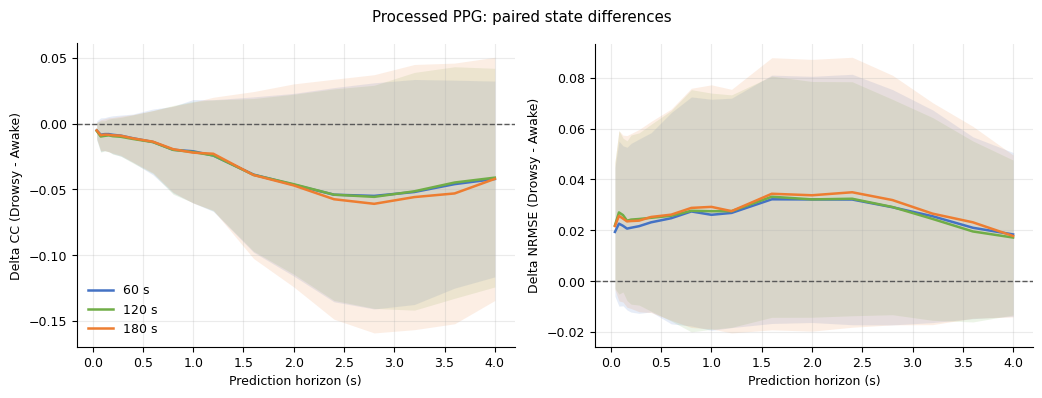

Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\simplex_projection\summary\processed_simplex_summary.csv


In [9]:
def across_session_state_curves(session_summary):
    """Summarize session-level state curves across sessions."""
    return (
        session_summary
        .groupby(
            ["state", "window_size_s", "horizon_seconds"],
            observed=True,
        )
        .agg(
            mean_cc=("central_cc", "mean"),
            sd_cc=("central_cc", "std"),
            mean_nrmse=("central_nrmse", "mean"),
            sd_nrmse=("central_nrmse", "std"),
            n_sessions=("session", "nunique"),
        )
        .reset_index()
    )


def across_session_difference_curves(state_differences):
    """Summarize paired state differences across sessions."""
    return (
        state_differences
        .groupby(["window_size_s", "horizon_seconds"], observed=True)
        .agg(
            mean_delta_cc=("delta_cc", "mean"),
            sd_delta_cc=("delta_cc", "std"),
            mean_delta_nrmse=("delta_nrmse", "mean"),
            sd_delta_nrmse=("delta_nrmse", "std"),
            n_sessions=("session", "nunique"),
        )
        .reset_index()
    )


def plot_state_curves(session_summary, representation, output_path):
    """Plot Awake and Drowsy prediction curves with session variability."""
    curve_summary = across_session_state_curves(session_summary)
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(10.5, 10.0),
        sharex=True,
    )
    metric_settings = (
        ("mean_cc", "sd_cc", "CC(h)"),
        ("mean_nrmse", "sd_nrmse", "NRMSE(h)"),
    )

    for row, window_size in enumerate(WINDOW_SIZES):
        for column, (mean_name, sd_name, ylabel) in enumerate(
            metric_settings
        ):
            axis = axes[row, column]
            for state in STATE_ORDER:
                subset = curve_summary.loc[
                    curve_summary["window_size_s"].eq(window_size)
                    & curve_summary["state"].eq(state)
                ].sort_values("horizon_seconds")
                x = subset["horizon_seconds"].to_numpy()
                mean = subset[mean_name].to_numpy()
                sd = subset[sd_name].fillna(0.0).to_numpy()
                axis.plot(
                    x,
                    mean,
                    color=STATE_COLORS[state],
                    linewidth=1.8,
                    label=state,
                )
                axis.fill_between(
                    x,
                    mean - sd,
                    mean + sd,
                    color=STATE_COLORS[state],
                    alpha=0.15,
                    linewidth=0,
                )
            axis.set_ylabel(ylabel)
            axis.set_title(f"{window_size} s windows")
            axis.axvline(0.0, color="0.5", linewidth=0.7)
            if row == len(WINDOW_SIZES) - 1:
                axis.set_xlabel("Prediction horizon (s)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=2,
        frameon=False,
    )
    figure.suptitle(
        f"{representation} PPG: Awake versus Drowsy",
        y=0.995,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.925))
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_state_differences(state_differences, representation, output_path):
    """Plot paired session-level state-difference curves."""
    curve_summary = across_session_difference_curves(state_differences)
    figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharex=True)
    settings = (
        ("mean_delta_cc", "sd_delta_cc", "Delta CC"),
        ("mean_delta_nrmse", "sd_delta_nrmse", "Delta NRMSE"),
    )

    for axis, (mean_name, sd_name, ylabel) in zip(axes, settings):
        for window_size in WINDOW_SIZES:
            subset = curve_summary.loc[
                curve_summary["window_size_s"].eq(window_size)
            ].sort_values("horizon_seconds")
            x = subset["horizon_seconds"].to_numpy()
            mean = subset[mean_name].to_numpy()
            sd = subset[sd_name].fillna(0.0).to_numpy()
            axis.plot(
                x,
                mean,
                color=SIZE_COLORS[window_size],
                linewidth=1.8,
                label=f"{window_size} s",
            )
            axis.fill_between(
                x,
                mean - sd,
                mean + sd,
                color=SIZE_COLORS[window_size],
                alpha=0.13,
                linewidth=0,
            )
        axis.axhline(0.0, color="0.35", linestyle="--", linewidth=1.0)
        axis.set_xlabel("Prediction horizon (s)")
        axis.set_ylabel(f"{ylabel} (Drowsy - Awake)")

    axes[0].legend(frameon=False)
    figure.suptitle(f"{representation} PPG: paired state differences")
    figure.tight_layout()
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


processed_summary_path = SUMMARY_DIR / "processed_simplex_summary.csv"
processed_session_summary.to_csv(processed_summary_path, index=False)
plot_state_curves(
    processed_session_summary,
    "Processed",
    SUMMARY_DIR / "processed_awake_vs_drowsy.png",
)
plot_state_differences(
    processed_state_differences,
    "Processed",
    SUMMARY_DIR / "processed_state_difference.png",
)
print(f"Saved: {processed_summary_path}")

## Part B — Raw PPG

### Cell 5 — Load and coverage

In [10]:
def load_raw_prediction_tasks():
    """Load SQI-passed Raw PPG windows without stationarity filtering."""
    prediction_tasks = []
    for session in sessions:
        batches, _ = load_segmented_session(
            session,
            data_dir=DATA_DIR,
            window_sizes=WINDOW_SIZES,
            representation="raw",
            stationarity_only=False,
        )
        for window_size in WINDOW_SIZES:
            batch = batches[window_size]
            for state, label in STATE_CODES.items():
                selected = np.flatnonzero(batch["label"] == label)
                for index in selected:
                    prediction_tasks.append(
                        {
                            "session": session,
                            "state": state,
                            "window_size_s": window_size,
                            "window_id": int(batch["window_id"][index]),
                            "fs": float(batch["fs"]),
                            "signal": np.asarray(
                                batch["signal"][index],
                                dtype=float,
                            ),
                        }
                    )
    return prediction_tasks


raw_tasks = load_raw_prediction_tasks()
raw_coverage, raw_coverage_audit = summarize_task_coverage(raw_tasks)
raw_coverage_issues = raw_coverage_audit.loc[
    raw_coverage_audit["coverage_status"].ne("adequate")
]

print(f"Raw SQI-passed windows: {len(raw_tasks):,}")
print("Raw stationarity filtering: not applied")
display(
    raw_coverage
    .groupby(["state", "window_size_s"], observed=True)
    .agg(
        n_sessions=("session", "nunique"),
        n_windows=("n_windows", "sum"),
        minimum_per_session=("n_windows", "min"),
    )
    .reset_index()
)
display(raw_coverage_issues)

Raw SQI-passed windows: 1,637
Raw stationarity filtering: not applied


,state,window_size_s,n_sessions,n_windows,minimum_per_session
0,Awake,60,20,623,19
1,Awake,120,20,284,8
2,Awake,180,20,168,5
3,Drowsy,60,20,328,8
4,Drowsy,120,20,148,3
5,Drowsy,180,20,86,1


,session,state,window_size_s,n_windows,coverage_status
4,sample_1,Drowsy,120,3,low_support
5,sample_1,Drowsy,180,1,low_support
29,sample_7,Drowsy,180,3,low_support
35,sample_8,Drowsy,180,3,low_support
46,sample_10,Drowsy,120,4,low_support
47,sample_10,Drowsy,180,2,low_support
76,sample_15,Drowsy,120,4,low_support
77,sample_15,Drowsy,180,1,low_support
83,sample_17,Drowsy,180,4,low_support
94,sample_19,Drowsy,120,4,low_support


### Cell 6 — Frozen prediction and aggregation

In [11]:
raw_start_time = time.perf_counter()
raw_rows = Parallel(n_jobs=N_JOBS, batch_size=1, verbose=5)(
    delayed(evaluate_frozen_task)(
        task,
        RAW_TAU_SECONDS,
        "Raw",
    )
    for task in raw_tasks
)
raw_window_results = pd.DataFrame(
    [row for task_rows in raw_rows for row in task_rows]
)
raw_runtime_minutes = (time.perf_counter() - raw_start_time) / 60

expected_raw_rows = len(raw_tasks) * len(HORIZON_SECONDS)
assert len(raw_window_results) == expected_raw_rows

raw_session_summary = aggregate_session_results(raw_window_results)
raw_state_differences = calculate_state_differences(raw_session_summary)
raw_qc = pd.DataFrame(
    {
        "n_rows": [len(raw_window_results)],
        "failed_rows": [raw_window_results["status"].ne("ok").sum()],
        "undefined_cc": [raw_window_results["cc"].isna().sum()],
        "undefined_nrmse": [raw_window_results["nrmse"].isna().sum()],
        "minimum_valid_fraction": [raw_window_results["valid_fraction"].min()],
        "runtime_minutes": [raw_runtime_minutes],
    }
)
raw_pair_coverage = (
    raw_state_differences
    .groupby("window_size_s", observed=True)
    .agg(
        n_paired_sessions=("session", "nunique"),
        n_horizons=("horizon_seconds", "nunique"),
    )
    .reset_index()
)

display(raw_qc)
display(raw_pair_coverage)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    1.2s


[Parallel(n_jobs=6)]: Done  60 tasks      | elapsed:   18.0s


[Parallel(n_jobs=6)]: Done 150 tasks      | elapsed:   28.0s


[Parallel(n_jobs=6)]: Done 276 tasks      | elapsed:   39.9s


...

[Parallel(n_jobs=6)]: Done 1140 tasks      | elapsed:  2.3min


[Parallel(n_jobs=6)]: Done 1446 tasks      | elapsed:  2.8min


[Parallel(n_jobs=6)]: Done 1637 out of 1637 | elapsed:  3.2min finished


,n_rows,failed_rows,undefined_cc,undefined_nrmse,minimum_valid_fraction,runtime_minutes
0,29466,0,0,0,1.0,3.175164


,window_size_s,n_paired_sessions,n_horizons
0,60,20,18
1,120,20,18
2,180,20,18


### Cell 7 — Raw final outputs

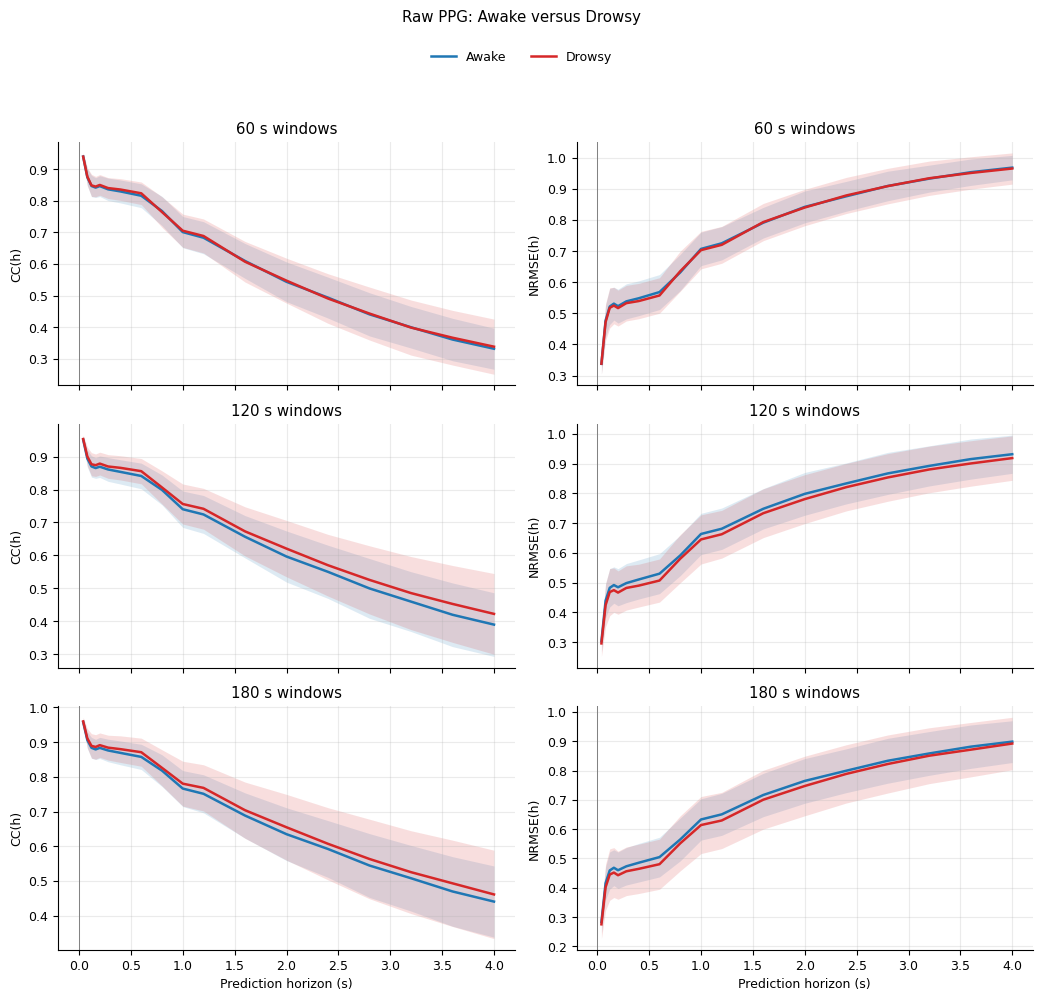

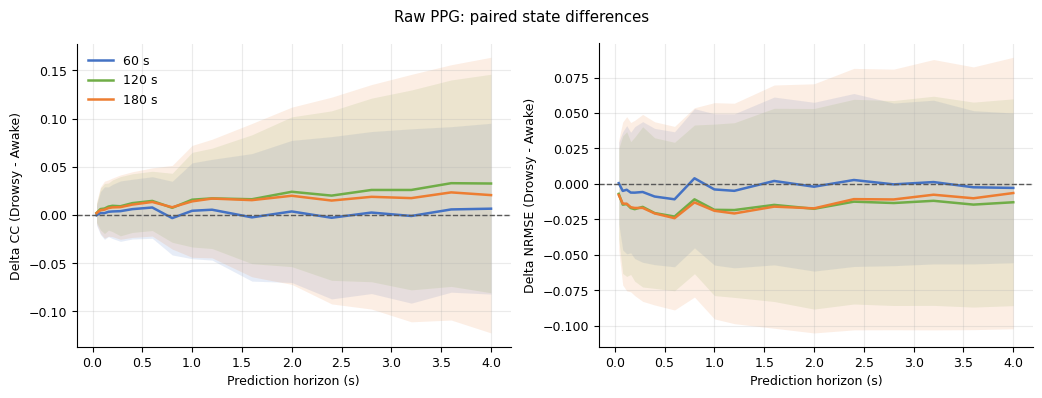

Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\simplex_projection\summary\raw_simplex_summary.csv


In [12]:
raw_summary_path = SUMMARY_DIR / "raw_simplex_summary.csv"
raw_session_summary.to_csv(raw_summary_path, index=False)
plot_state_curves(
    raw_session_summary,
    "Raw",
    SUMMARY_DIR / "raw_awake_vs_drowsy.png",
)
plot_state_differences(
    raw_state_differences,
    "Raw",
    SUMMARY_DIR / "raw_state_difference.png",
)
print(f"Saved: {raw_summary_path}")

## Part C — Cross-representation comparison

### Cell 8 — Merge comparable session-level results

In [13]:
session_merge_keys = [
    "session",
    "state",
    "window_size_s",
    "horizon_seconds",
]
session_columns = session_merge_keys + [
    "central_cc",
    "central_nrmse",
    "n_windows",
    "mean_valid_fraction",
]
comparable_session_summary = processed_session_summary[
    session_columns
].merge(
    raw_session_summary[session_columns],
    on=session_merge_keys,
    suffixes=("_processed", "_raw"),
    validate="one_to_one",
)

difference_merge_keys = [
    "session",
    "window_size_s",
    "horizon_seconds",
]
difference_columns = difference_merge_keys + ["delta_cc", "delta_nrmse"]
comparable_state_differences = processed_state_differences[
    difference_columns
].merge(
    raw_state_differences[difference_columns],
    on=difference_merge_keys,
    suffixes=("_processed", "_raw"),
    validate="one_to_one",
)
comparable_state_differences["representation_difference_cc"] = (
    comparable_state_differences["delta_cc_raw"]
    - comparable_state_differences["delta_cc_processed"]
)
comparable_state_differences["representation_difference_nrmse"] = (
    comparable_state_differences["delta_nrmse_raw"]
    - comparable_state_differences["delta_nrmse_processed"]
)

comparable_coverage = (
    comparable_state_differences
    .groupby("window_size_s", observed=True)
    .agg(
        n_paired_sessions=("session", "nunique"),
        n_horizons=("horizon_seconds", "nunique"),
    )
    .reset_index()
)
display(comparable_coverage)

,window_size_s,n_paired_sessions,n_horizons
0,60,20,18
1,120,20,18
2,180,20,18


### Cell 9 — Representation-dependent state effects

In [14]:
def direction_agreement(frame, metric):
    """Return agreement in the sign of two representation effects."""
    processed_sign = np.sign(frame[f"delta_{metric}_processed"])
    raw_sign = np.sign(frame[f"delta_{metric}_raw"])
    return float(np.mean(processed_sign == raw_sign))


cross_rows = []
for (window_size, horizon), group in comparable_state_differences.groupby(
    ["window_size_s", "horizon_seconds"],
    observed=True,
):
    row = {
        "window_size_s": window_size,
        "horizon_seconds": horizon,
        "n_paired_sessions": group["session"].nunique(),
    }
    for metric in ("cc", "nrmse"):
        for representation in ("processed", "raw"):
            values = group[f"delta_{metric}_{representation}"]
            prefix = f"delta_{metric}_{representation}"
            row[f"mean_{prefix}"] = values.mean()
            row[f"sd_{prefix}"] = values.std()
            row[f"median_{prefix}"] = values.median()
            row[f"iqr_{prefix}"] = interquartile_range(values)
            row[f"fraction_positive_{prefix}"] = values.gt(0).mean()

        difference = group[f"representation_difference_{metric}"]
        row[f"mean_representation_difference_{metric}"] = difference.mean()
        row[f"sd_representation_difference_{metric}"] = difference.std()
        row[f"median_representation_difference_{metric}"] = (
            difference.median()
        )
        row[f"iqr_representation_difference_{metric}"] = (
            interquartile_range(difference)
        )
        row[f"direction_agreement_{metric}"] = direction_agreement(
            group,
            metric,
        )
    cross_rows.append(row)

cross_representation_summary = pd.DataFrame(cross_rows).sort_values(
    ["window_size_s", "horizon_seconds"]
)

display(cross_representation_summary.head())

,window_size_s,horizon_seconds,n_paired_sessions,mean_delta_cc_processed,sd_delta_cc_processed,median_delta_cc_processed,iqr_delta_cc_processed,fraction_positive_delta_cc_processed,mean_delta_cc_raw,sd_delta_cc_raw,...,mean_delta_nrmse_raw,sd_delta_nrmse_raw,median_delta_nrmse_raw,iqr_delta_nrmse_raw,fraction_positive_delta_nrmse_raw,mean_representation_difference_nrmse,sd_representation_difference_nrmse,median_representation_difference_nrmse,iqr_representation_difference_nrmse,direction_agreement_nrmse
0,60,0.04,20,-0.005185,0.007130,-0.005805,0.009534,0.25,-0.000271,0.010295,...,0.000467,0.028752,0.000721,0.039616,0.55,-0.018856,0.026142,-0.014522,0.031411,0.70
1,60,0.08,20,-0.008499,0.012807,-0.010127,0.015563,0.25,0.002019,0.022314,...,-0.005013,0.041718,-0.001431,0.056486,0.45,-0.027593,0.034346,-0.024220,0.031542,0.60
2,60,0.12,20,-0.008027,0.012523,-0.010381,0.015903,0.25,0.001941,0.027230,...,-0.004182,0.045239,0.002482,0.042113,0.55,-0.025923,0.030933,-0.029448,0.034821,0.80
3,60,0.16,20,-0.008012,0.013362,-0.009661,0.013829,0.25,0.003317,0.025784,...,-0.006174,0.042538,-0.004671,0.041082,0.45,-0.026802,0.029033,-0.021446,0.040467,0.70
4,60,0.20,20,-0.008546,0.014445,-0.010220,0.016670,0.25,0.003665,0.028060,...,-0.006224,0.046516,-0.001588,0.071657,0.50,-0.027191,0.038896,-0.028290,0.065997,0.65


### Cell 10 — Final RQ2 outputs and findings

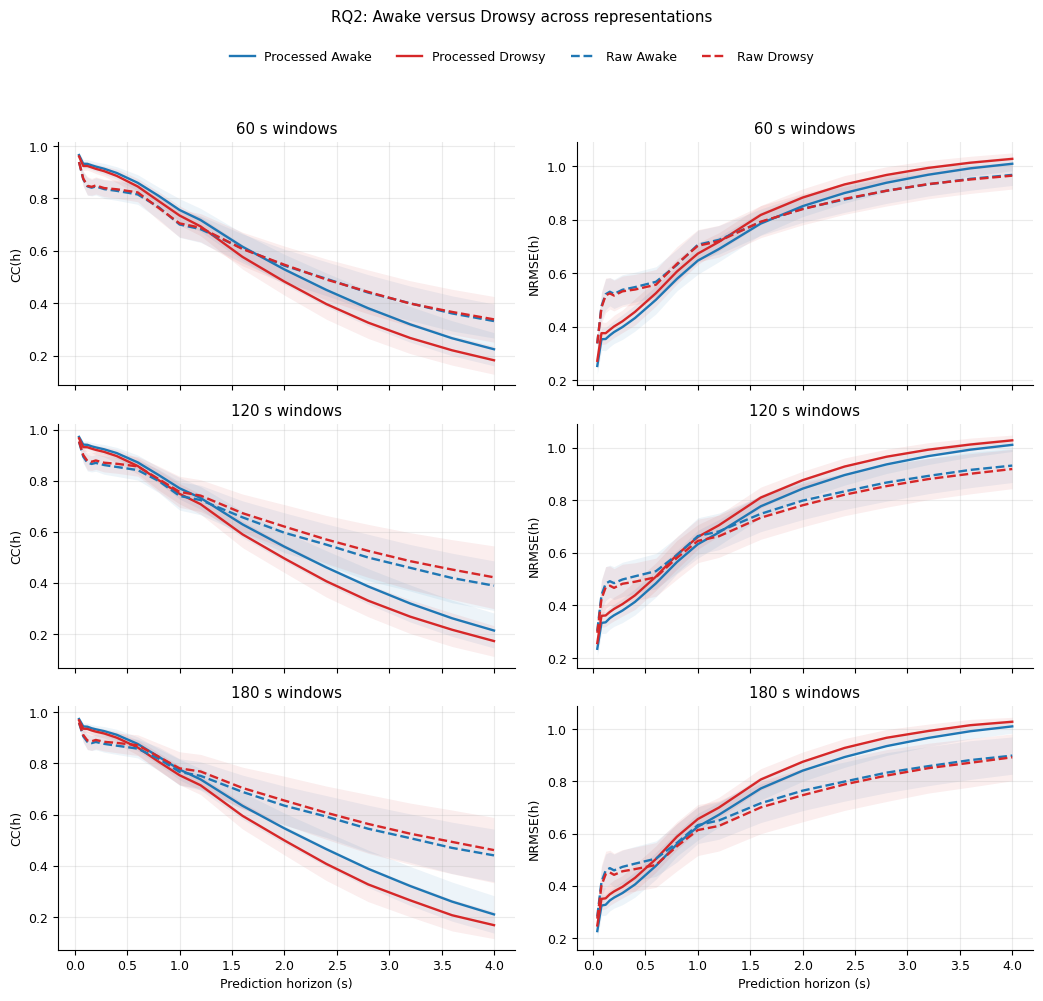

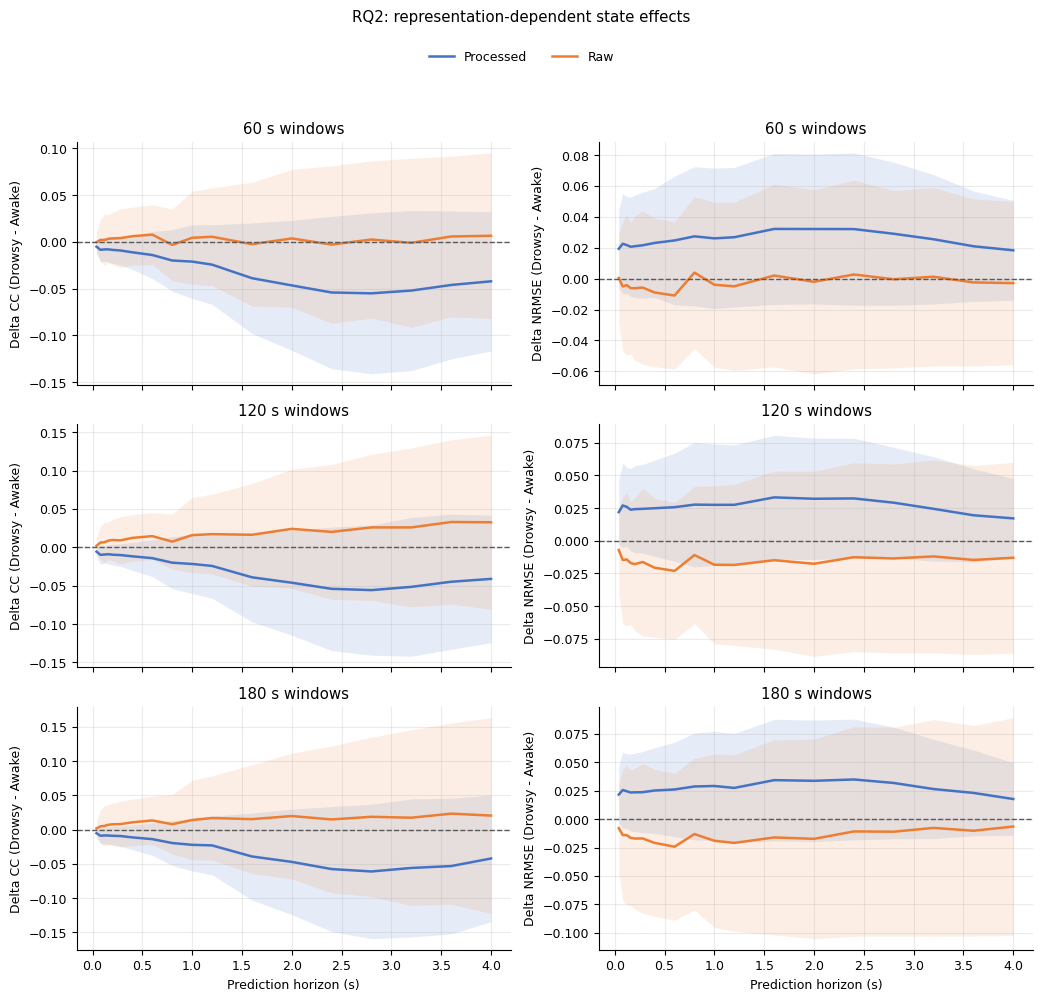

,representation,window_size_s,n_sessions,mean_delta_cc,sd_delta_cc,fraction_delta_cc_positive,mean_delta_nrmse,sd_delta_nrmse,fraction_delta_nrmse_positive
0,Processed,60,20,-0.0263,0.0413,0.25,0.0247,0.0375,0.75
1,Processed,120,20,-0.0265,0.0414,0.20,0.0260,0.0366,0.80
2,Processed,180,20,-0.0275,0.0449,0.25,0.0268,0.0388,0.75
3,Raw,60,20,0.0026,0.0484,0.45,-0.0030,0.0474,0.45
4,Raw,120,20,0.0160,0.0522,0.60,-0.0154,0.0556,0.40
5,Raw,180,20,0.0128,0.0637,0.60,-0.0147,0.0708,0.50


### RQ2 findings

Bảng trên tóm tắt hiệu ứng `Drowsy - Awake` sau khi lấy trung bình đường dự báo theo horizon trong từng session. Các hình và bảng sử dụng session làm đơn vị độc lập; dấu và độ lớn của hiệu ứng được trình bày riêng cho từng representation và window size. Đây là bằng chứng mô tả cho RQ2, không phải kiểm định determinism hoặc surrogate testing.

Final RQ2 outputs:
- processed_awake_vs_drowsy.png
- processed_simplex_summary.csv
- processed_state_difference.png
- raw_awake_vs_drowsy.png
- raw_simplex_summary.csv
- raw_state_difference.png
- simplex_raw_vs_processed_state_effect.png
- simplex_raw_vs_processed_summary.csv
- simplex_rq2_awake_vs_drowsy.png


In [15]:
def plot_cross_state_curves(output_path):
    """Plot state curves for both signal representations."""
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(10.5, 10.0),
        sharex=True,
    )
    settings = (("cc", "CC(h)"), ("nrmse", "NRMSE(h)"))
    line_styles = {"Processed": "-", "Raw": "--"}

    for row, window_size in enumerate(WINDOW_SIZES):
        size_data = comparable_session_summary.loc[
            comparable_session_summary["window_size_s"].eq(window_size)
        ]
        for column, (metric, ylabel) in enumerate(settings):
            axis = axes[row, column]
            for representation in ("Processed", "Raw"):
                representation_key = representation.lower()
                value_column = f"central_{metric}_{representation_key}"
                for state in STATE_ORDER:
                    subset = size_data.loc[size_data["state"].eq(state)]
                    curve = (
                        subset
                        .groupby("horizon_seconds", observed=True)[value_column]
                        .agg(["mean", "std"])
                        .reset_index()
                    )
                    x = curve["horizon_seconds"].to_numpy()
                    mean = curve["mean"].to_numpy()
                    sd = curve["std"].fillna(0.0).to_numpy()
                    label = f"{representation} {state}"
                    axis.plot(
                        x,
                        mean,
                        color=STATE_COLORS[state],
                        linestyle=line_styles[representation],
                        linewidth=1.7,
                        label=label,
                    )
                    axis.fill_between(
                        x,
                        mean - sd,
                        mean + sd,
                        color=STATE_COLORS[state],
                        alpha=0.08,
                        linewidth=0,
                    )
            axis.set_title(f"{window_size} s windows")
            axis.set_ylabel(ylabel)
            if row == len(WINDOW_SIZES) - 1:
                axis.set_xlabel("Prediction horizon (s)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=4,
        frameon=False,
    )
    figure.suptitle("RQ2: Awake versus Drowsy across representations", y=0.995)
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.925))
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_cross_state_effect(output_path):
    """Plot paired state effects for Raw and Processed PPG."""
    figure, axes = plt.subplots(
        3,
        2,
        figsize=(10.5, 10.0),
        sharex=True,
    )
    settings = (("cc", "Delta CC"), ("nrmse", "Delta NRMSE"))

    for row, window_size in enumerate(WINDOW_SIZES):
        size_data = comparable_state_differences.loc[
            comparable_state_differences["window_size_s"].eq(window_size)
        ]
        for column, (metric, ylabel) in enumerate(settings):
            axis = axes[row, column]
            for representation in ("Processed", "Raw"):
                representation_key = representation.lower()
                value_column = f"delta_{metric}_{representation_key}"
                curve = (
                    size_data
                    .groupby("horizon_seconds", observed=True)[value_column]
                    .agg(["mean", "std"])
                    .reset_index()
                )
                x = curve["horizon_seconds"].to_numpy()
                mean = curve["mean"].to_numpy()
                sd = curve["std"].fillna(0.0).to_numpy()
                axis.plot(
                    x,
                    mean,
                    color=REPRESENTATION_COLORS[representation],
                    linewidth=1.8,
                    label=representation,
                )
                axis.fill_between(
                    x,
                    mean - sd,
                    mean + sd,
                    color=REPRESENTATION_COLORS[representation],
                    alpha=0.13,
                    linewidth=0,
                )
            axis.axhline(
                0.0,
                color="0.35",
                linestyle="--",
                linewidth=1.0,
            )
            axis.set_title(f"{window_size} s windows")
            axis.set_ylabel(f"{ylabel} (Drowsy - Awake)")
            if row == len(WINDOW_SIZES) - 1:
                axis.set_xlabel("Prediction horizon (s)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=2,
        frameon=False,
    )
    figure.suptitle("RQ2: representation-dependent state effects", y=0.995)
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.925))
    figure.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


cross_summary_path = (
    SUMMARY_DIR / "simplex_raw_vs_processed_summary.csv"
)
cross_representation_summary.to_csv(cross_summary_path, index=False)
plot_cross_state_curves(
    SUMMARY_DIR / "simplex_rq2_awake_vs_drowsy.png"
)
plot_cross_state_effect(
    SUMMARY_DIR / "simplex_raw_vs_processed_state_effect.png"
)

finding_parts = []
for representation, differences in (
    ("Processed", processed_state_differences),
    ("Raw", raw_state_differences),
):
    session_curve_effects = (
        differences
        .groupby(["session", "window_size_s"], observed=True)
        .agg(
            delta_cc=("delta_cc", "mean"),
            delta_nrmse=("delta_nrmse", "mean"),
        )
        .reset_index()
    )
    summary = (
        session_curve_effects
        .groupby("window_size_s", observed=True)
        .agg(
            n_sessions=("session", "nunique"),
            mean_delta_cc=("delta_cc", "mean"),
            sd_delta_cc=("delta_cc", "std"),
            fraction_delta_cc_positive=("delta_cc", lambda x: x.gt(0).mean()),
            mean_delta_nrmse=("delta_nrmse", "mean"),
            sd_delta_nrmse=("delta_nrmse", "std"),
            fraction_delta_nrmse_positive=(
                "delta_nrmse",
                lambda x: x.gt(0).mean(),
            ),
        )
        .reset_index()
    )
    summary.insert(0, "representation", representation)
    finding_parts.append(summary)

rq2_findings = pd.concat(finding_parts, ignore_index=True)
display(rq2_findings.round(4))
finding_note = (
    "### RQ2 findings\n\n"
    "Bảng trên tóm tắt hiệu ứng `Drowsy - Awake` sau khi lấy trung bình "
    "đường dự báo theo horizon trong từng session. Các hình và bảng sử "
    "dụng session làm đơn vị độc lập; dấu và độ lớn của hiệu ứng được "
    "trình bày riêng cho từng representation và window size. Đây là bằng "
    "chứng mô tả cho RQ2, không phải kiểm định determinism hoặc surrogate "
    "testing."
)
display(Markdown(finding_note))

expected_outputs = {
    "processed_simplex_summary.csv",
    "raw_simplex_summary.csv",
    "simplex_raw_vs_processed_summary.csv",
    "processed_awake_vs_drowsy.png",
    "processed_state_difference.png",
    "raw_awake_vs_drowsy.png",
    "raw_state_difference.png",
    "simplex_rq2_awake_vs_drowsy.png",
    "simplex_raw_vs_processed_state_effect.png",
}
saved_outputs = {path.name for path in SUMMARY_DIR.iterdir() if path.is_file()}
missing_outputs = expected_outputs.difference(saved_outputs)
assert not missing_outputs, f"Missing final outputs: {sorted(missing_outputs)}"

print("Final RQ2 outputs:")
for name in sorted(expected_outputs):
    print(f"- {name}")

# Tổng hợp kết quả RQ2

## Protocol cố định

- Simplex Projection được thực hiện với `m = 8`, `k = 9`, Theiler window `W = 1,0 s` và prediction horizon tối đa `4 s`.
- Embedding delay được cố định theo representation: Processed `tau = 0,16 s`, Raw `tau = 0,20 s`.
- Processed PPG dùng các window qua SQI và processed-stationarity; Raw PPG dùng các window qua SQI, không lọc stationarity.
- Kết quả được tổng hợp theo thứ tự: window → session × state × window size → across-session. Window không được pool trực tiếp giữa các session.

## Coverage và chất lượng kết quả

| Representation | Số window | Số kết quả window–horizon | Prediction failure | Minimum valid fraction |
|---|---:|---:|---:|---:|
| Processed | 1.544 | 27.792 | 0 | 1,000 |
| Raw | 1.637 | 29.466 | 0 | 1,000 |

Cả ba window size `60/120/180 s` đều có đủ 20 session ghép cặp Awake–Drowsy. Không có CC hoặc NRMSE không xác định.

## Awake–Drowsy state effect

Các giá trị dưới đây là `Delta = Drowsy − Awake`, sau khi lấy trung bình đường dự báo theo horizon trong từng session và tổng hợp trên 20 session.

| Representation | Window size | Mean Delta CC | Mean Delta NRMSE | Tỷ lệ Delta CC > 0 | Tỷ lệ Delta NRMSE > 0 |
|---|---:|---:|---:|---:|---:|
| Processed | 60 s | −0,0263 | +0,0247 | 25% | 75% |
| Processed | 120 s | −0,0265 | +0,0260 | 20% | 80% |
| Processed | 180 s | −0,0275 | +0,0268 | 25% | 75% |
| Raw | 60 s | +0,0026 | −0,0030 | 45% | 45% |
| Raw | 120 s | +0,0160 | −0,0154 | 60% | 40% |
| Raw | 180 s | +0,0128 | −0,0147 | 60% | 50% |

## Kết quả chính

- Trên Processed PPG, Drowsy có CC thấp hơn và NRMSE cao hơn Awake. Hướng và độ lớn trung bình của hiệu ứng tương đối ổn định giữa `60/120/180 s`.
- Trên Raw PPG, state effect nhỏ hơn, có variability across-session lớn hơn và hướng kém nhất quán hơn Processed.
- State-difference curves của Raw và Processed không đồng nhất. Kết quả RQ2 vì vậy phụ thuộc rõ vào representation và preprocessing.
- Các kết quả cung cấp bằng chứng mô tả về sự khác biệt nonlinear predictability giữa Awake và Drowsy trên Processed PPG. Chúng chưa phải kiểm định thống kê xác nhận state effect và không được diễn giải như bằng chứng về determinism hoặc chaos.

## Kết luận RQ2

Với protocol đã đóng băng, Processed PPG cho thấy Drowsy có khả năng dự báo thấp hơn Awake một cách nhất quán hơn Raw PPG. Tuy nhiên, do hiệu ứng không được bảo toàn giữa hai representation, kết luận chính cần được trình bày là **state-dependent nonlinear predictability có bằng chứng trên Processed PPG nhưng mang tính representation-dependent**. Surrogate testing và inference cho determinism vẫn được giữ cho phân tích riêng.


````markdown
# Kết luận thực nghiệm Simplex Projection và định hướng tiếp theo

## 1. Trạng thái phương pháp

Simplex Projection đã được **validated và freeze** với protocol:

```text
m = 8
k = 9

tau:
    Processed = 0.16 s
    Raw       = 0.20 s

Theiler window:
    W = 1.0 s

Prediction horizon:
    Hmax = 4 s

Distance:
    Euclidean

Weighting:
    exponential simplex weighting

Prediction:
    leave-one-out state-space prediction
    + temporal exclusion

Metrics:
    CC(h)
    NRMSE(h)
````

Phân tích tuân theo hierarchy:

```text
Window
→ Session × State × Window Size
→ Across-session
```

`session` là đơn vị inference; các window không được pool trực tiếp giữa các session.

---

## 2. Kết quả mô tả chính cho RQ2

### Processed PPG

Trên cả `60 / 120 / 180 s`, Drowsy cho:

```text
CC(h) ↓
NRMSE(h) ↑
```

so với Awake.

Mean paired state effects ổn định theo window size:

```text
Delta CC ≈ -0.026 đến -0.028
Delta NRMSE ≈ +0.025 đến +0.027
```

Pattern này cho thấy:

> Drowsiness liên quan đến giảm khả năng dự báo của reconstructed Processed-PPG dynamics.

State separation nhỏ ở horizon rất ngắn và rõ hơn khi prediction horizon tăng.

### Raw PPG

Raw PPG cho:

```text
state effect nhỏ hơn
direction kém nhất quán hơn
across-session variability lớn hơn
```

so với Processed PPG.

Do đó prediction evidence cho thấy:

> state-dependent nonlinear predictability mang tính representation-dependent.

---

## 3. Insight chính từ Prediction

Simplex Projection không chỉ cung cấp một prediction score đơn lẻ mà tạo ra:

```text
CC(h)
NRMSE(h)
```

như một **dynamical predictability profile**.

Kết quả cho thấy Awake và Drowsy khác nhau về:

```text
mức forecastability
+
cách forecast skill suy giảm theo horizon
```

Đặc biệt trên Processed PPG:

> Drowsy có predictability thấp hơn Awake một cách nhất quán qua 60–180 s.

---

## 4. Insight về window length

State-dependent prediction pattern trên Processed PPG giữ cùng hướng ở:

```text
60 s
120 s
180 s
```

Các cửa sổ dài hơn không làm thay đổi rõ direction của effect.

Điều này tạo ra một giả thuyết engineering:

> **60 s có thể chứa phần lớn state-dependent nonlinear predictability information cần thiết, với latency và computational cost thấp hơn 120–180 s.**

Hiện tại đây mới là descriptive insight.

Để gọi 60 s là:

```text
sufficient
equivalent
non-inferior
```

cần phân tích riêng ở session level.

---

## 5. Contribution khoa học hiện tại của Prediction

Prediction hiện cung cấp **descriptive NTSA evidence đầu tiên cho RQ2**.

Nó định lượng:

```text
local trajectory evolution
/
short-term forecastability
```

của reconstructed phase space.

Contribution hiện tại không phải:

```text
một CC đơn lẻ
một NRMSE đơn lẻ
một horizon tối ưu
```

mà là bằng chứng rằng:

> **Awake và Drowsy biểu hiện các prediction-skill profiles khác nhau trong reconstructed PPG dynamics, và mức độ khác biệt phụ thuộc vào signal representation.**

Prediction alone chưa cho phép kết luận:

```text
determinism
chaos
chaos-to-chaos transition
```

---

## 6. Kết hợp với RQA

RQA đã cung cấp loại bằng chứng NTSA thứ hai:

```text
Simplex Prediction:
    local temporal evolution / predictability

RQA:
    recurrence geometry / trajectory organization /
    laminar persistence
```

Hai phương pháp cùng chỉ ra rằng:

> Awake và Drowsy không chỉ khác nhau về waveform statistics mà còn khác nhau trong cách reconstructed dynamics được tổ chức.

Đặc biệt:

```text
Processed PPG:
    prediction skill ↓ trong Drowsy
    diagonal recurrence organization ↓
    laminar organization ↑

Raw PPG:
    prediction state effect yếu hơn
    recurrence persistence / laminar structure tăng rõ hơn
```

Điều này gợi ý rằng Raw và Processed có thể quan sát **các mặt bổ sung của cùng state-dependent dynamics**.

---

## 7. Working interpretation cho RQ2

Kết luận an toàn hiện tại:

> **Drowsiness is associated with a systematic and representation-dependent reorganization of reconstructed PPG dynamics. Simplex Projection shows reduced forecastability in Processed PPG during drowsiness, while RQA reveals concurrent changes in recurrence organization and laminar persistence. Together, these methods provide converging descriptive nonlinear dynamical evidence for differences between Awake and Drowsy states.**

Chưa được nâng thành causal hoặc chaotic interpretation.

---

## 8. Các bước tiếp theo để trở thành scientific contribution

### Step 1 — Session-level inference cho RQ2

Đánh giá:

```text
paired Awake–Drowsy effects
effect sizes
confidence intervals
sign consistency
multiple-comparison control
```

Inference giữ `session` là đơn vị thống kê.

### Step 2 — Window-length robustness

So sánh trực tiếp:

```text
60 s vs 120 s vs 180 s
```

trên session-level effects của cả:

```text
Prediction
RQA
```

Mục tiêu:

> kiểm tra liệu 60 s có bảo tồn phần lớn dynamical state effect hay không.

### Step 3 — Cross-representation inference

Định lượng trực tiếp:

```text
Raw state effect
vs
Processed state effect
```

thay vì chỉ mô tả riêng từng representation.

Đây sẽ hỗ trợ phần representation-dependent của RQ2/RQ3.

### Step 4 — Surrogate testing cho RQ1

Sau khi Prediction và RQA đều đã freeze:

```text
Original window
→ Frozen Prediction + Frozen RQA

vs

Surrogate ensemble
→ cùng Frozen Prediction + Frozen RQA
```

Mục tiêu:

> kiểm tra liệu observed predictability và recurrence organization có vượt khỏi stochastic / pseudoperiodic null phù hợp hay không.

Chỉ sau bước này mới đánh giá:

```text
deterministic nonlinear dynamics
```

và nếu evidence đủ mạnh hơn nữa:

```text
chaos-to-chaos transition
```

---

## 9. Scientific contribution tiềm năng

Nếu session-level inference và surrogate testing xác nhận các pattern hiện tại, contribution trung tâm có thể được phát biểu là:

> **Awake and drowsy PPG represent distinct nonlinear dynamical regimes characterized by coordinated changes in local predictability and recurrence organization. These changes are robust across analysis windows but are expressed differently in Raw and Processed PPG representations.**

Nếu surrogate testing đồng thời cho thấy cả Awake và Drowsy đều chứa nonlinear deterministic organization vượt null, framing có thể được nâng lên:

```text
state transition between two distinct deterministic nonlinear regimes
```

và chỉ khi có thêm bằng chứng đủ mạnh mới xem xét:

```text
chaos-to-chaos transition
```

---

## 10. Trạng thái hiện tại

```text
Phase-space reconstruction     CLOSED
Simplex Projection             CLOSED
RQA                            CLOSED

RQ2 descriptive evidence       AVAILABLE

RQ2 formal inference           NEXT
Window-length robustness       NEXT
Cross-representation inference NEXT

RQ1 surrogate testing          DEFERRED
Determinism / chaos claim      NOT YET ALLOWED
```

```
```
